<h1 align="center" style="background-color:#0b0504;color:white;border-radius: 8px; padding:15px">Maize Disease Detection using CNN</h1>

In [10]:
import PIL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import Precision, Recall, F1Score

import warnings
warnings.filterwarnings('ignore')

In [11]:
data_dir = 'corn/data'
batch_size = 32
img_height = 256
img_width = 256
seed = 123

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, 
    validation_split=0.2, # 20% of data for validation
    subset="training",
    seed=seed,
    image_size=(img_width, img_height),
    batch_size=batch_size
)

Found 12360 files belonging to 4 classes.
Using 9888 files for training.


In [13]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% of data for validation
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 12360 files belonging to 4 classes.
Using 2472 files for validation.


In [14]:
# Split the validation set into validation and test sets
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

In [15]:
class_names = train_ds.class_names
print(class_names)

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [16]:
# Prefetch data for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

<h3 style="background-color:#0b0504;color:white;border-radius: 8px; padding:15px">3. Visualize Data</h3>

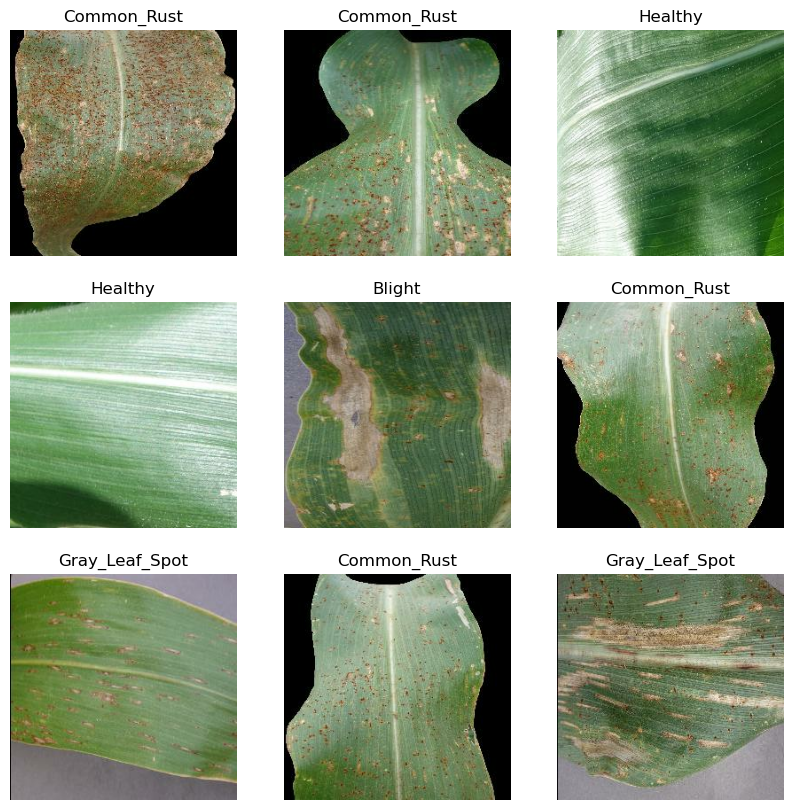

In [17]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

<h3 style="background-color:#0b0504;color:white;border-radius: 8px; padding:15px">4. Data Normalization</h3>

In [18]:
resize_and_rescale = tf.keras.Sequential([
tf.keras.layers.Resizing(256,256),
tf.keras.layers.Rescaling(1.0/255)
])

In [19]:
train_ds = train_ds.map(lambda x, y: (resize_and_rescale(x), y))
val_ds = val_ds.map(lambda x, y: (resize_and_rescale(x), y))
test_ds = test_ds.map(lambda x, y: (resize_and_rescale(x), y))

<h3 style="background-color:#0b0504;color:white;border-radius: 8px; padding:15px">5. Define Utility Plotting Functions</h3>

In [20]:
def evaluate(model, data, data_type):
    # Get the true labels and the predicted labels
    y_true = np.concatenate([y for x, y in data], axis=0)
    y_pred_probs = model.predict(data)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    
    # Print metrics
    print(f'{data_type} Accuracy: {accuracy}')
    print(f'{data_type} Precision: {precision}')
    print(f'{data_type} Recall: {recall}')
    print(f'{data_type} F1-Score: {f1}')
    
    return accuracy, precision, recall, f1, cm

In [21]:
def plot_confusion_matrix(cm, class_names, model_name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

In [22]:
def plot_loss_accuracy(history, model_name):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    
    plt.figure(figsize=(20,5))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'ro-', label='train loss')
    plt.plot(val_loss, 'bo-', label='val loss')
    plt.title(f'{model_name} Training & Validation Loss', fontsize=12)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid()
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(train_accuracy, 'ro-', label='train accuracy')
    plt.plot(val_accuracy, 'bo-', label='val accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid()
    
    plt.show()

In [23]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    
    return predicted_class, confidence

In [24]:
def prediction_plot(model, test_set, class_names):
    plt.figure(figsize=(15, 20))  # Adjust the figure size as needed

    images_shown = 0
    rows = 4
    cols = 3

    for images, labels in test_set.take(1):
        for i in range(min(rows * cols, len(images))):  # Ensure we iterate over a maximum of rows*cols images
            if images_shown >= rows * cols:
                break

            ax = plt.subplot(rows, cols, images_shown + 1)  # Calculate the correct subplot index
            plt.imshow(images[i])

            predicted_class, confidence = predict(model, images[i])
            index = labels[i].argmax(axis=0)
            actual_class = class_names[index]

            plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=10)
            plt.axis("off")

            images_shown += 1

        if images_shown >= rows * cols:
            break

    plt.tight_layout()
    plt.show()

<h3 style="background-color:#0b0504;color:white;border-radius: 8px; padding:15px">6. Basic Keras Model</h3>

In [25]:
num_classes = len(class_names)
input_shape = (img_height, img_width, 3)
epoch = 15

In [26]:
model = Sequential([
    layers.Conv2D(32,(3,3),activation ='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])

In [27]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,812 (718.02 KB)

 Trainable params: 183,812 (718.02 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epoch
)

Epoch 1/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7029 - loss: 0.6168 - val_accuracy: 0.8995 - val_loss: 0.2219
Epoch 2/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9158 - loss: 0.2146 - val_accuracy: 0.9069 - val_loss: 0.1970
Epoch 3/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.9453 - loss: 0.1371 - val_accuracy: 0.9493 - val_loss: 0.1381
Epoch 4/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.9572 - loss: 0.1223 - val_accuracy: 0.9469 - val_loss: 0.1501
Epoch 5/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.9432 - loss: 0.1439 - val_accuracy: 0.9583 - val_loss: 0.1141
Epoch 6/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.9548 - loss: 0.1107 - val_accuracy: 0.9551 - val_loss: 0.1155
Epoch 7/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - accuracy: 0.9611 - loss: 0.1028 - val_accuracy: 0.9673 - val_loss: 0.0875
Epoch 8/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.9715 - loss: 0.0748 - val_accu

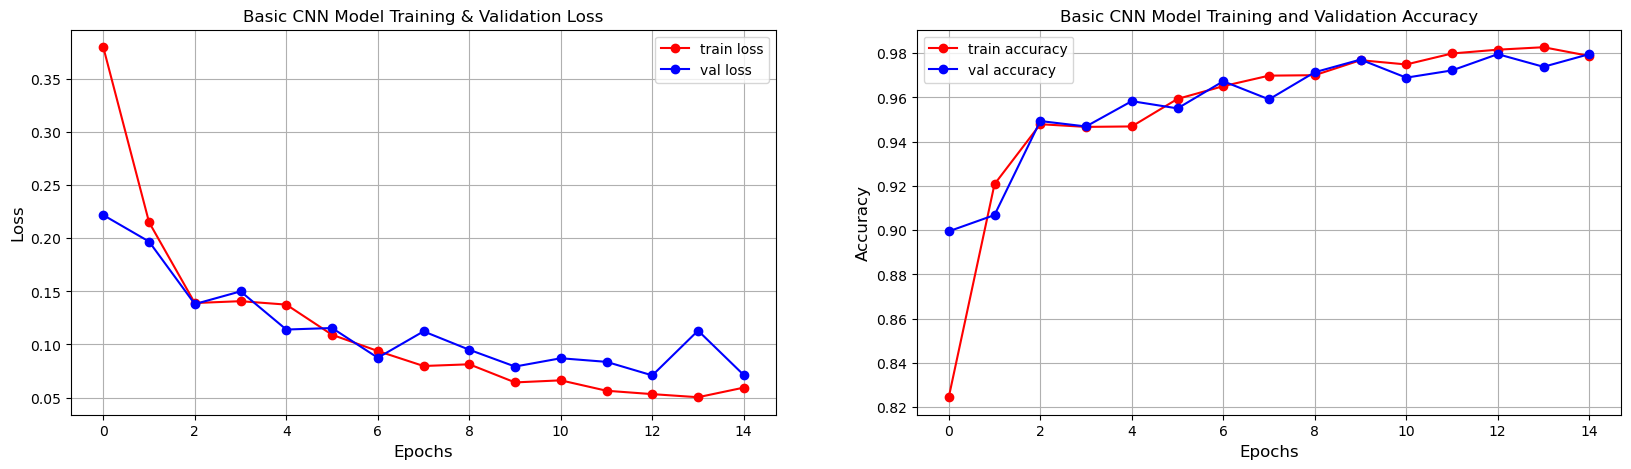

In [30]:
plot_loss_accuracy(history, 'Basic CNN Model')

In [31]:
accuracy, precision, recall, f1, cm = evaluate(model, val_ds, data_type='Validation')

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step
Validation Accuracy: 0.9795751633986928
Validation Precision: 0.9799935665298516
Validation Recall: 0.9795751633986928
Validation F1-Score: 0.9796203195968437


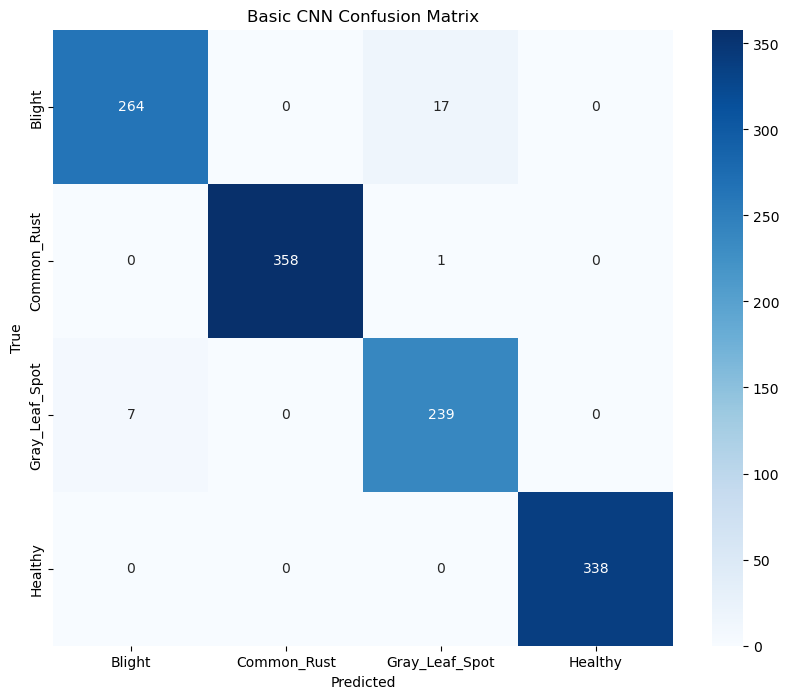

In [32]:
# Plot confusion matrix
plot_confusion_matrix(cm, class_names, model_name='Basic CNN')
plt.show()

In [33]:
def prediction_plot(model, test_set, class_names):
    plt.figure(figsize=(15, 20))  # Adjust the figure size as needed

    images_shown = 0
    rows = 4
    cols = 3

    for images, labels in test_set.take(1):
        for i in range(min(rows * cols, len(images))):  # Ensure we iterate over a maximum of rows*cols images
            if images_shown >= rows * cols:
                break

            ax = plt.subplot(rows, cols, images_shown + 1)  # Calculate the correct subplot index
            plt.imshow(images[i])

            predicted_class, confidence = predict(model, images[i])
#             index = labels[i].max(axis=0)
            actual_class = class_names[labels[i]]

            plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=10)
            plt.axis("off")

            images_shown += 1

        if images_shown >= rows * cols:
            break

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


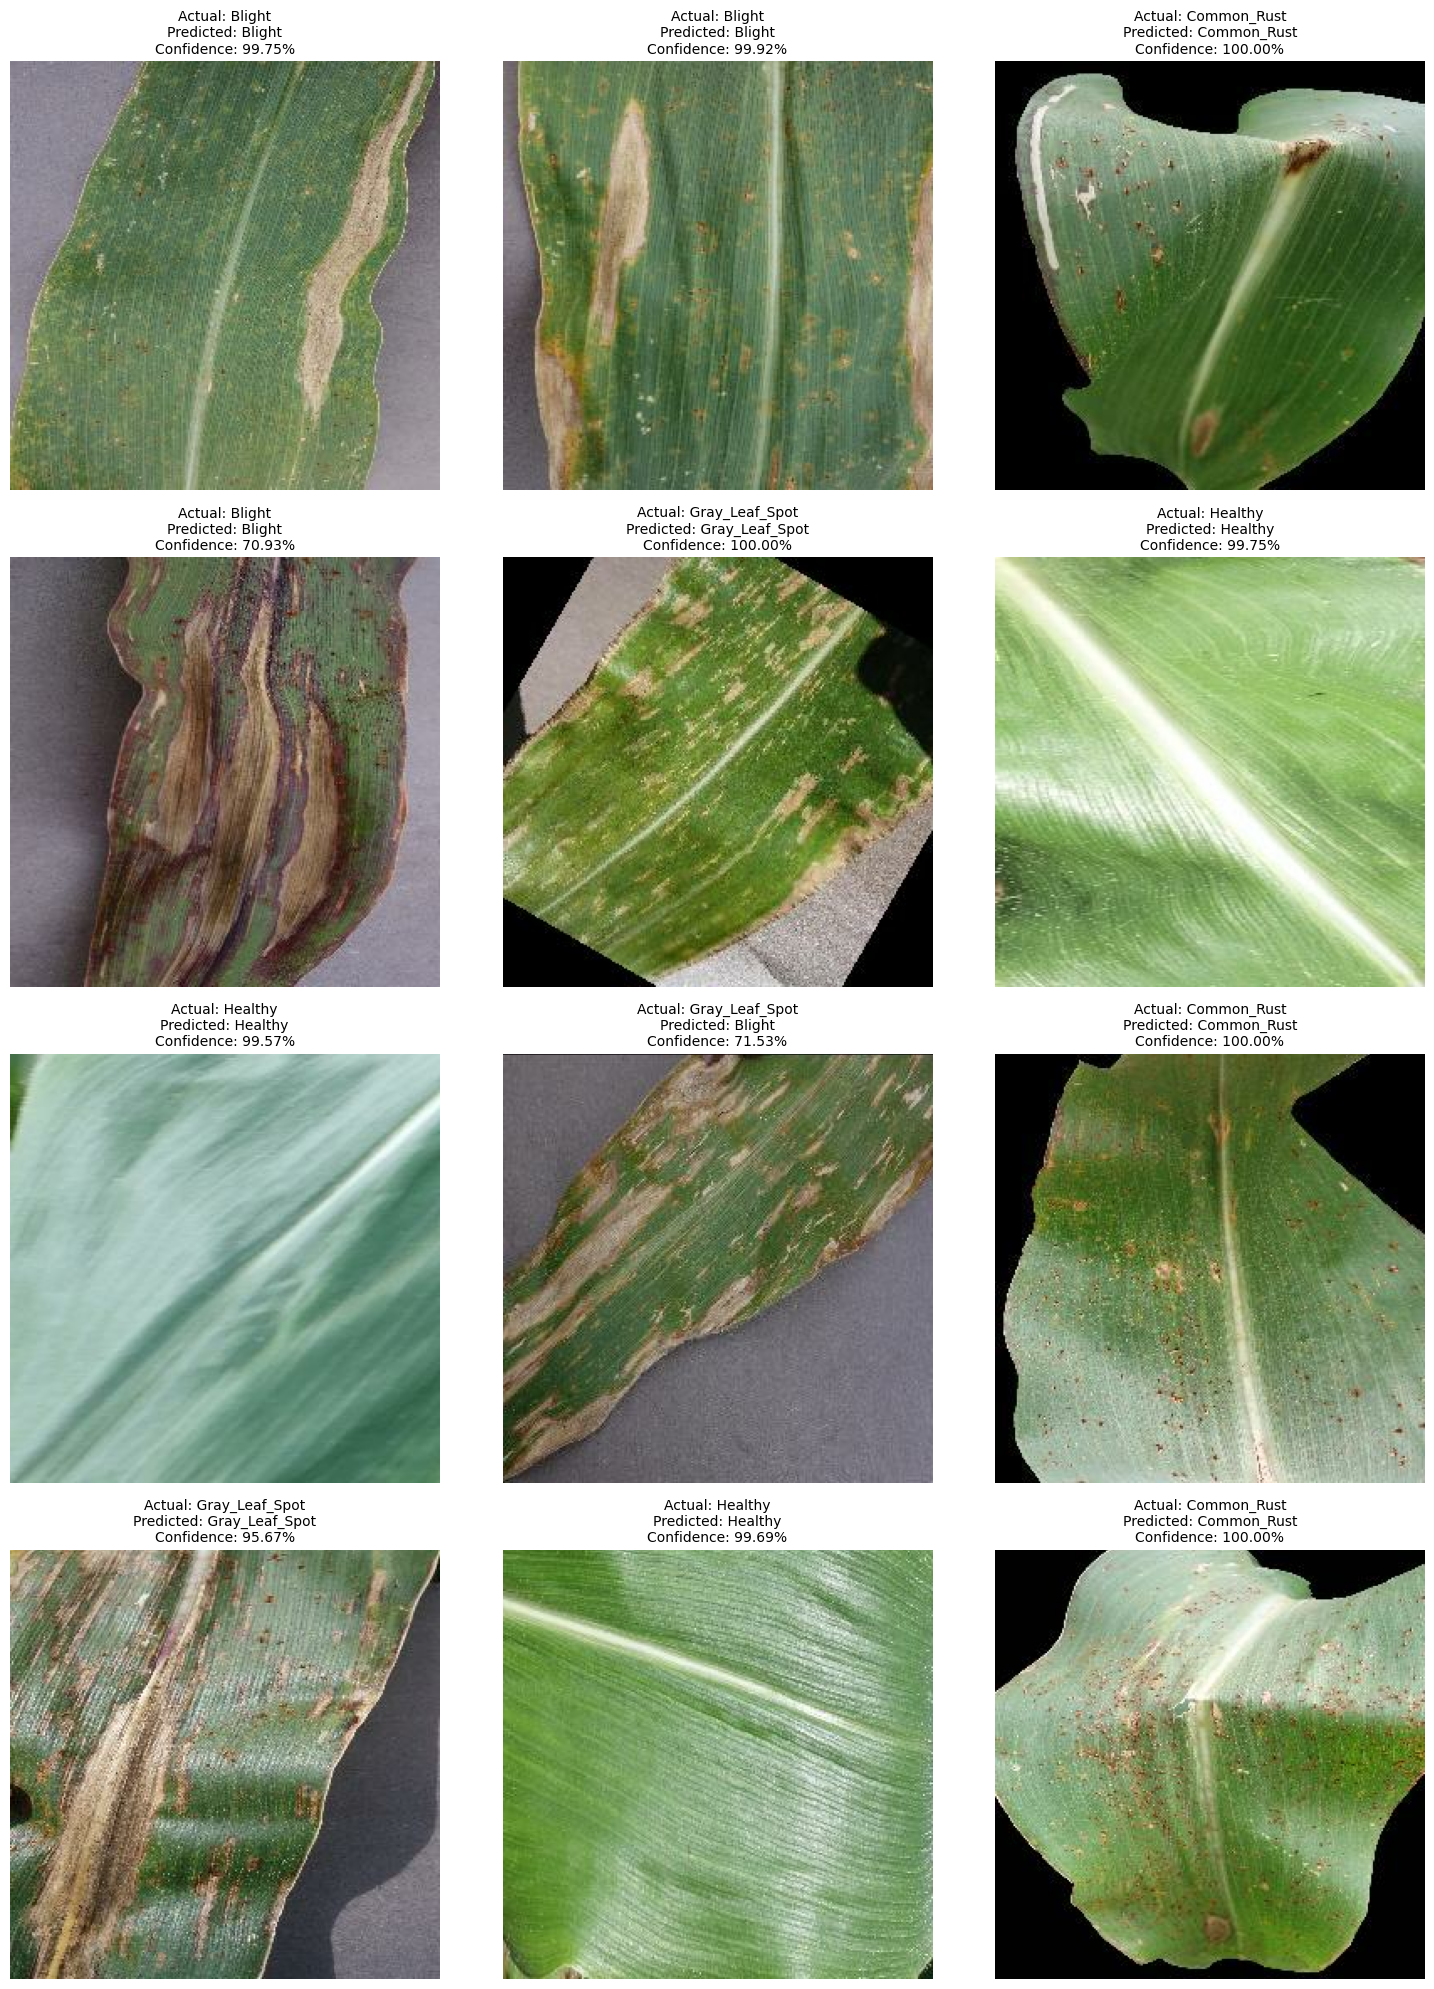

In [34]:
prediction_plot(model, test_ds, class_names)

In [35]:
accuracy, precision, recall, f1, cm = evaluate(model, test_ds, data_type='Test')

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step
Test Accuracy: 0.969551282051282
Test Precision: 0.9699300984433921
Test Recall: 0.969551282051282
Test F1-Score: 0.9695644139888966


In [36]:
model.save('Maizeplant_disease_model.h5')

In [37]:
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite model to a file
with open('Maizeplant_disease_model1.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\MRLAPT~1\AppData\Local\Temp\tmph507uuhx\assets


INFO:tensorflow:Assets written to: C:\Users\MRLAPT~1\AppData\Local\Temp\tmph507uuhx\assets


Saved artifact at 'C:\Users\MRLAPT~1\AppData\Local\Temp\tmph507uuhx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1893175313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175314000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175314960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175314192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175315344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175315152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175317264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175317072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1893175317840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted Class: Blight
Confidence: 100.0%


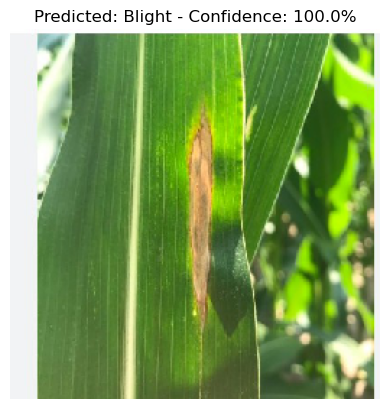

In [38]:
from tensorflow.keras.preprocessing import image

def test_single_image(model, img_path):
    # Load the image from file
    img = image.load_img(img_path, target_size=(img_height, img_width))
    
    # Preprocess the image: convert to array, expand dimensions, and rescale
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale to [0, 1]

    # Make the prediction
    predictions = model.predict(img_array)
    
    # Get the predicted class and confidence
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)

    # Display the results
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence}%")

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} - Confidence: {confidence}%")
    plt.axis('off')
    plt.show()

# Test on a single image (replace with the path to your test image)
test_single_image(model, 'image1.jpg')
